## Level 1 – Task 1
#### 1. Determine the top three most common cuisines in the dataset.
#### 2. Calculate the percentage of restaurants that serve each of the top three cuisines.

In [33]:
import pandas as pd

# Load the Dataset
df = pd.read_csv('Dataset .csv')

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [34]:
# Split multiple cuisines and count each cuisine
cuisine_counts = (
    df["Cuisines"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)



# Top 3 cuisines
top_3 = cuisine_counts.head(3)

# Calculate percentage
percentage = (top_3 / len(df)) * 100

result = pd.DataFrame({
    "Cuisine": top_3.index,
    "Restaurant Count": top_3.values,
    "Percentage": percentage.values
})

print(result)

        Cuisine  Restaurant Count  Percentage
0  North Indian              3960   41.461627
1       Chinese              2735   28.635745
2     Fast Food              1986   20.793634


## Level 1 – Task 2
#### 1. Identify the city with the highest number of restaurants in the dataset.
#### 2. Calculate the average rating for restaurants in each city.
#### 3. Determine the city with the highest average rating.


In [35]:
city_counts = df["City"].value_counts()

print("\n ------City_Counts:-------")
city_counts.head(10)


 ------City_Counts:-------


City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64

In [36]:
city_rating = df.groupby("City")["Aggregate rating"].mean().sort_values(ascending=False)

print("\n------City Ratings:------")
city_rating.head(10)


------City Ratings:------


City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64

### Final conclusion

New Delhi has the highest number of restaurants in the dataset, with 5,473 restaurants. 

Based on the average Aggregate Rating, Inner City has the highest average rating of 4.90.

## Level 1 – Task 3
#### 1. Create a visualisation (histogram or bar chart) to show the distribution of price ranges among the restaurants.
#### 2. Calculate the percentage of restaurants in each price range category.



In [37]:
# Price range count
price_count = df["Price range"].value_counts().sort_index()

print(price_count)

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


In [38]:
# Count restaurants in each price range
price_count = df["Price range"].value_counts().sort_index()

# Calculate percentage
price_percentage = (price_count / len(df)) * 100

# Create result table
result = pd.DataFrame({
    "Restaurant Count": price_count,
    "Percentage": price_percentage.round(2)
})

result



,Restaurant Count,Percentage
Price range,,
1,4444,46.53
2,3113,32.59
3,1408,14.74
4,586,6.14


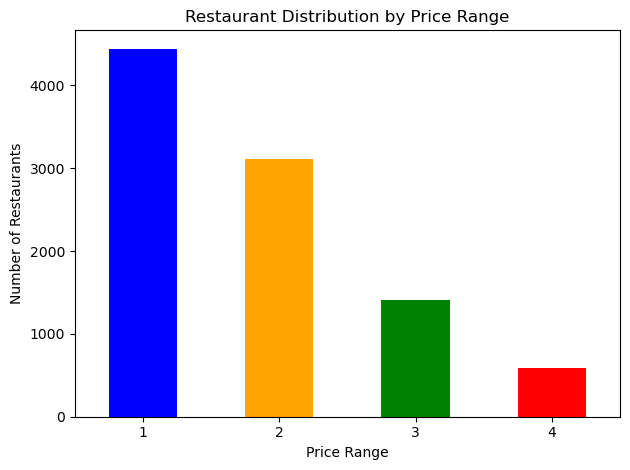

In [39]:
import matplotlib.pyplot as plt

# Bar chart with different colors
price_count.plot(
    kind="bar",
    color=["blue", "orange", "green", "red"]
)

plt.title("Restaurant Distribution by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Level 1 – Task 4
#### 1. Determine the percentage of restaurants that offer online delivery.
#### 2. Compare the average ratings of restaurants with and without online delivery.

In [40]:
delivery_count = df["Has Online delivery"].value_counts()

delivery_percentage = (delivery_count / len(df)) * 100

delivery_result = pd.DataFrame({
    "Restaurant Count": delivery_count,
    "Percentage": delivery_percentage.round(2)
})

delivery_result

,Restaurant Count,Percentage
Has Online delivery,,
No,7100,74.34
Yes,2451,25.66


In [41]:
average_rating = df.groupby("Has Online delivery")["Aggregate rating"].mean()

average_rating.round(2)

Has Online delivery
No     2.47
Yes    3.25
Name: Aggregate rating, dtype: float64

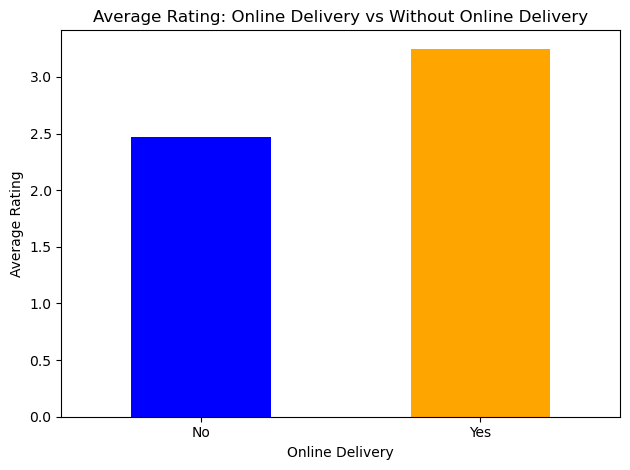

In [42]:
import matplotlib.pyplot as plt

average_rating.plot(
    kind="bar",
    color=["blue", "orange"]
)

plt.title("Average Rating: Online Delivery vs Without Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Level 2 – Task 1
#### 1. Analyze the distribution of aggregate ratings and determine the most common rating range.
#### 2. Calculate the average number of votes received by restaurants.

In [43]:
df["Aggregate rating"].value_counts().sort_index()


Aggregate rating
0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     498
3.5     480
3.6     458
3.7     427
3.8     400
3.9     335
4.0     266
4.1     274
4.2     221
4.3     174
4.4     144
4.5      95
4.6      78
4.7      42
4.8      25
4.9      61
Name: count, dtype: int64

In [44]:
df["Votes"].mean()

np.float64(156.909747670401)

## Level 2 – Task 2
#### 1.  Identify the most common combinations of cuisines in the dataset.
#### 2. Determine if certain cuisine combinations tend to have higher ratings.

In [45]:
# Count the most common cuisine combinations
cuisine_combinations = df["Cuisines"].value_counts()

print("\n------Cuisine Counts:------")
print(cuisine_combinations.head(10))


------Cuisine Counts:------
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


In [46]:
# Calculate average rating for each cuisine combination
cuisine_rating = (
    df.groupby("Cuisines")["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
)

print("\n------Average Ratings by Cuisine:------")
print(cuisine_rating.head(10))


------Average Ratings by Cuisine:------
Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64


In [47]:
cuisine_analysis = df.groupby("Cuisines").agg(
    Restaurant_Count=("Cuisines", "size"),
    Average_Rating=("Aggregate rating", "mean")
)

cuisine_analysis = cuisine_analysis.sort_values(
    by="Restaurant_Count",
    ascending=False
)

cuisine_analysis.head(10)

,Restaurant_Count,Average_Rating
Cuisines,,
North Indian,936,1.672329
"North Indian, Chinese",511,2.421722
Chinese,354,2.042090
Fast Food,354,2.118362
"North Indian, Mughlai",334,2.888623
Cafe,299,2.890970
Bakery,218,1.924312
"North Indian, Mughlai, Chinese",197,2.568528
"Bakery, Desserts",170,2.317647


## Level 2 – Task 3
#### 1.  Plot the locations of restaurants on a map using longitude and latitude coordinates.
#### 2. Identify any patterns or clusters of restaurants in specific areas.

In [48]:
df[["Latitude", "Longitude"]].head()

,Latitude,Longitude
0,14.565443,121.027535
1,14.553708,121.014101
2,14.581404,121.056831
3,14.585318,121.056475
4,14.584450,121.057508


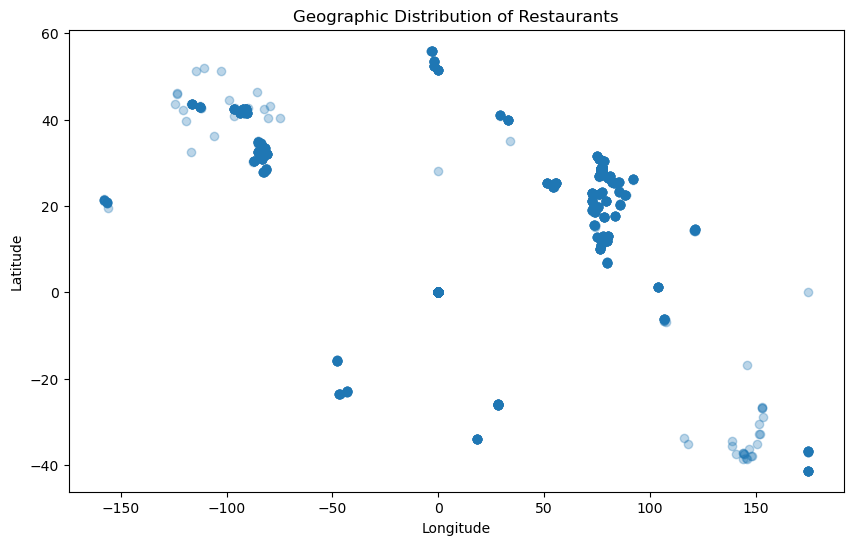

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    alpha=0.3
)

plt.title("Geographic Distribution of Restaurants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

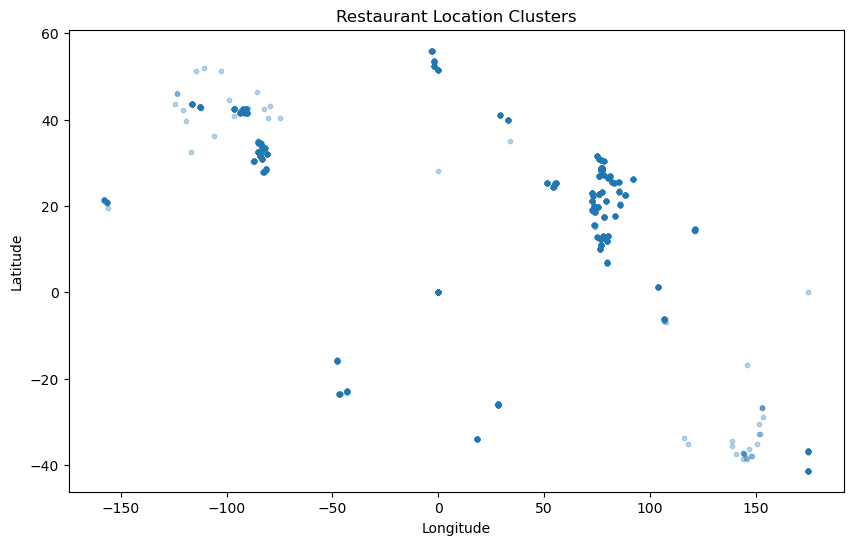

In [50]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    s=10,
    alpha=0.3
)

plt.title("Restaurant Location Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

## Lavel 2 Task 4
#### 1. Identify if there are any restaurant chains present in the dataset.
#### 2. Analyze the ratings and popularity of different restaurant chains.


In [51]:
restaurant_counts = df["Restaurant Name"].value_counts()
print("\n------Restaurant Counts:------")
print(restaurant_counts.head(10))


------Restaurant Counts:------
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


In [52]:
chains = restaurant_counts[restaurant_counts > 1]
print("\n------Chain Restaurant Counts:------")
print(chains.head(20))


------Chain Restaurant Counts:------
Restaurant Name
Cafe Coffee Day        83
Domino's Pizza         79
Subway                 63
Green Chick Chop       51
McDonald's             48
Keventers              34
Pizza Hut              30
Giani                  29
Baskin Robbins         28
Barbeque Nation        26
Dunkin' Donuts         22
Barista                22
Giani's                22
Pind Balluchi          20
Costa Coffee           20
Wah Ji Wah             19
Pizza Hut Delivery     19
Sagar Ratna            19
Twenty Four Seven      19
Republic of Chicken    18
Name: count, dtype: int64


In [53]:
chain_analysis = df.groupby("Restaurant Name").agg(
    Restaurant_Count=("Restaurant Name", "size"),
    Average_Rating=("Aggregate rating", "mean"),
    Total_Votes=("Votes", "sum")
)

chain_analysis = chain_analysis[
    chain_analysis["Restaurant_Count"] > 1
].sort_values(
    by="Restaurant_Count",
    ascending=False
)

chain_analysis.head(20)

,Restaurant_Count,Average_Rating,Total_Votes
Restaurant Name,,,
Cafe Coffee Day,83,2.419277,2428
Domino's Pizza,79,2.740506,6643
Subway,63,2.907937,6124
Green Chick Chop,51,2.672549,964
McDonald's,48,3.339583,5291
Keventers,34,2.870588,1263
Pizza Hut,30,3.320000,4961
Giani,29,2.689655,854
Baskin Robbins,28,1.860714,428


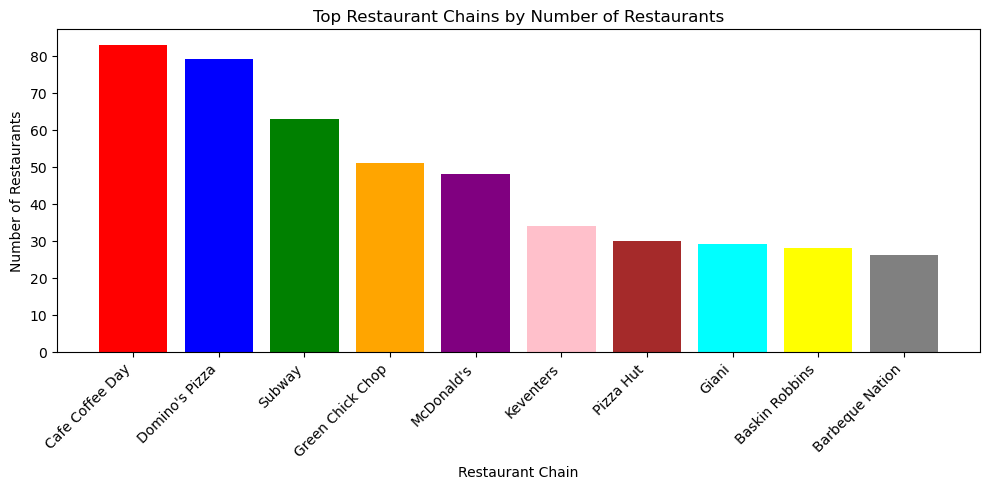

In [54]:
import matplotlib.pyplot as plt

top_chains = chain_analysis.head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top_chains.index,
    top_chains["Restaurant_Count"],
    color=[
        "red", "blue", "green", "orange", "purple",
        "pink", "brown", "cyan", "yellow", "gray"
    ]
)

plt.title("Top Restaurant Chains by Number of Restaurants")
plt.xlabel("Restaurant Chain")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Level 3 Task 1
#### 1.  Analyze the text reviews to identify the most common positive and negative keywords.
#### 2.  Calculate the average length of reviews and explore if there is a relationship between review length and rating.

In [55]:
df['Rating text'].value_counts()



Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64

In [56]:
# Rating ke basis par synthetic review generate karna
positive_reviews = [
    "Excellent food and amazing service. Great experience.",
    "Very good food, friendly service and delicious dishes.",
    "Amazing restaurant with great food and excellent service.",
    "Good food and nice atmosphere. Really enjoyed the experience."
]

negative_reviews = [
    "Poor food and slow service. Disappointing experience.",
    "Bad food and poor service. Not a good experience.",
    "Disappointing food and slow service. Needs improvement.",
    "Poor experience with bad food and unfriendly service."
]

neutral_reviews = [
    "Average food and service. The experience was okay.",
    "The food was average and the service was satisfactory.",
    "Decent food and service. Overall an average experience."
]

# Rating ke according positive, negative ya neutral review assign karna
def create_review(rating):
    if rating >= 4:
        return np.random.choice(positive_reviews)
    elif rating <= 2:
        return np.random.choice(negative_reviews)
    else:
        return np.random.choice(neutral_reviews)

# Dataset mein naya Review column banana
df["Review"] = df["Aggregate rating"].apply(create_review)

# Generated reviews check karna
df[["Restaurant Name", "Aggregate rating", "Rating text", "Review"]].head(10)

,Restaurant Name,Aggregate rating,Rating text,Review
0,Le Petit Souffle,4.8,Excellent,Amazing restaurant with great food and excelle...
1,Izakaya Kikufuji,4.5,Excellent,Good food and nice atmosphere. Really enjoyed ...
2,Heat - Edsa Shangri-La,4.4,Very Good,"Very good food, friendly service and delicious..."
3,Ooma,4.9,Excellent,Good food and nice atmosphere. Really enjoyed ...
4,Sambo Kojin,4.8,Excellent,Excellent food and amazing service. Great expe...
5,Din Tai Fung,4.4,Very Good,Excellent food and amazing service. Great expe...
6,Buffet 101,4.0,Very Good,"Very good food, friendly service and delicious..."
7,Vikings,4.2,Very Good,Good food and nice atmosphere. Really enjoyed ...
8,Spiral - Sofitel Philippine Plaza Manila,4.9,Excellent,"Very good food, friendly service and delicious..."
9,Locavore,4.8,Excellent,"Very good food, friendly service and delicious..."


In [57]:
# Har review ki length calculate karna
df["Review_Length"] = df["Review"].str.len()

# Sabhi reviews ki average length calculate karna
average_review_length = df["Review_Length"].mean()

print("\n-----Average Review Length:-----")
print("Average Review Length:", round(average_review_length, 2))


-----Average Review Length:-----
Average Review Length: 53.38


## Level 3 Task 2
#### 1. Identify the restaurants with the highest and lowest number of votes.
#### 2. Analyze if there is a correlation between the number of votes and the rating of a restaurant.


In [60]:
# Highest votes wale restaurants
highest_votes = df.sort_values(
    by="Votes",
    ascending=False
)

print("Top 10 Restaurants with Highest Votes:")
highest_votes[
    ["Restaurant Name", "City", "Votes", "Aggregate rating"]
].head(10)

Top 10 Restaurants with Highest Votes:


,Restaurant Name,City,Votes,Aggregate rating
728,Toit,Bangalore,10934,4.8
735,Truffles,Bangalore,9667,4.7
3994,Hauz Khas Social,New Delhi,7931,4.3
2412,Peter Cat,Kolkata,7574,4.3
739,AB's - Absolute Barbecues,Bangalore,6907,4.6
2414,Barbeque Nation,Kolkata,5966,4.9
743,Big Brewsky,Bangalore,5705,4.5
2307,AB's - Absolute Barbecues,Hyderabad,5434,4.9
736,The Black Pearl,Bangalore,5385,4.1
2411,BarBQ,Kolkata,5288,4.2


In [61]:
# Lowest votes wale restaurants
lowest_votes = df.sort_values(
    by="Votes",
    ascending=True
)

print("Top 10 Restaurants with Lowest Votes:")
lowest_votes[
    ["Restaurant Name", "City", "Votes", "Aggregate rating"]
].head(10)

Top 10 Restaurants with Lowest Votes:


,Restaurant Name,City,Votes,Aggregate rating
1173,Aha Bites,Gurgaon,0,0.0
1172,Achoos Food Corner,Gurgaon,0,0.0
8558,Food Town,Noida,0,0.0
6165,Zaika Restaurant,New Delhi,0,0.0
6164,Smily Cakes,New Delhi,0,0.0
6161,Roll Junction,New Delhi,0,0.0
1178,Gopi Sweets & Caters,Gurgaon,0,0.0
1186,Tanishk Gourmet Indian,Gurgaon,0,0.0
1185,Solty Hotel,Gurgaon,0,0.0
1183,OMG Tiffinz,Gurgaon,0,0.0


In [62]:
# Votes aur rating ke beech correlation calculate karna
correlation = df["Votes"].corr(
    df["Aggregate rating"]
)

print(
    "Correlation between Votes and Rating:",
    round(correlation, 3)
)

Correlation between Votes and Rating: 0.314


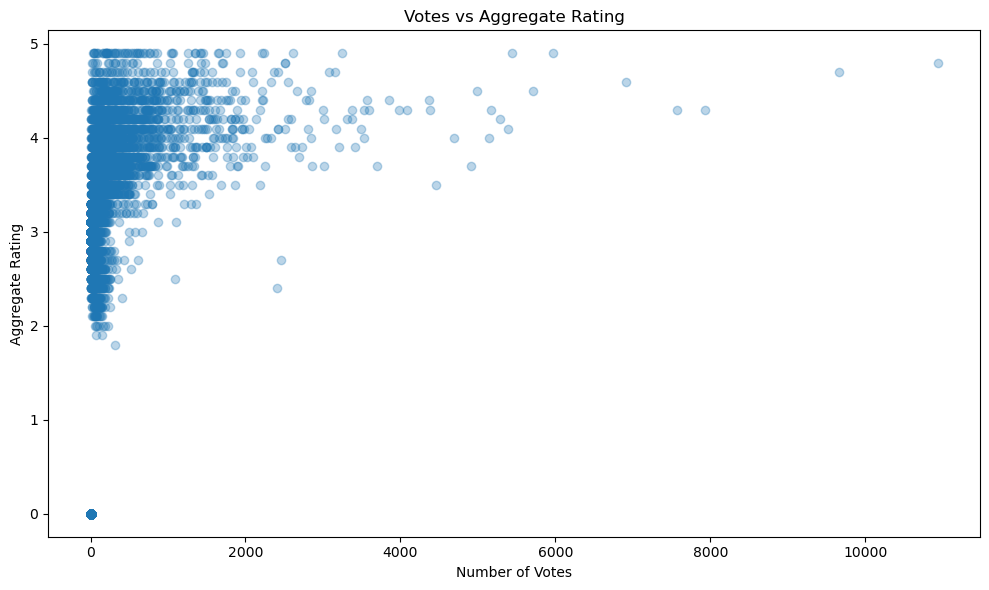

In [63]:
# Votes aur rating ka relationship visualize karna
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Votes"],
    df["Aggregate rating"],
    alpha=0.3
)

plt.title("Votes vs Aggregate Rating")
plt.xlabel("Number of Votes")
plt.ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()

## Level 3 Task 3
#### 1. Analyze if there is a relationship between the price range and the availability of online delivery and table booking.
#### 2. Determine if higher-priced restaurants are more likely to offer these services.